In [ ]:
import os; import pandas as pd
pd.options.display.float_format = '{:.3f}'.format
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
import numpy as np; import matplotlib.pyplot as plt
import gurobipy as gp; from gurobipy import GRB
from itertools import product; from tqdm import tqdm
import importlib
import functions_utils; import functions_data
import functions_optimize; import functions_eval
importlib.reload(functions_data); importlib.reload(functions_optimize)
importlib.reload(functions_eval); importlib.reload(functions_utils)
from functions_utils import *; from functions_data import *
from functions_optimize import *; from functions_eval import *
import time

✅ Figure successfully saved to:
C:\Users\jangseohyun\SynologyDrive\workspace\opt-pricing\fig_aggprof.pdf


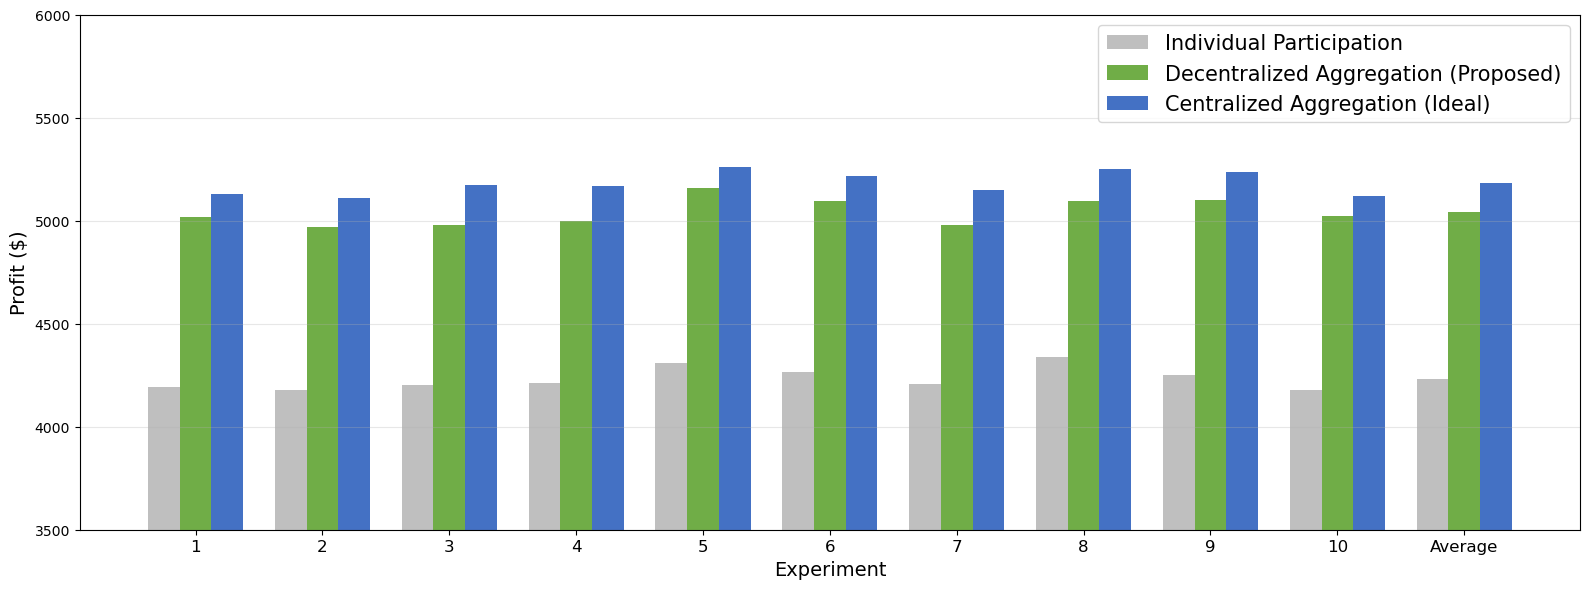

In [56]:
import matplotlib.pyplot as plt
import numpy as np

# Provided data
seeds = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
individual = [4191840, 4179595, 4203089, 4210119, 4307675, 4266959, 4204982, 4336559, 4249098, 4177077]
decentralized = [5016014, 4967221, 4977120, 4999863, 5156704, 5094140, 4978965, 5095049, 5100348, 5022855]
centralized = [5127532, 5109052, 5170583, 5165589, 5258677, 5217372, 5149085, 5248225, 5237931, 5118401]


# --- 1. Calculate and append the average values ---
# Calculate the average for each list
avg_individual = np.mean(np.array(individual)/1000)
avg_decentralized = np.mean(np.array(decentralized)/1000)
avg_centralized = np.mean(np.array(centralized)/1000)

# Append the averages to the end of the original data lists
individual_with_avg = [x/1000 for x in individual] + [avg_individual]
decentralized_with_avg = [x/1000 for x in decentralized] + [avg_decentralized]
centralized_with_avg = [x/1000 for x in centralized] + [avg_centralized]

# --- 2. Update the x-axis labels ---
# Add 'Average' as the last label on the x-axis
seeds_with_avg_label = [str(s) for s in seeds] + ['Average']


# --- 3. Plotting ---
# Set the positions for the bars (now 11 positions)
x = np.arange(len(seeds_with_avg_label))
width = 0.25

fig, ax = plt.subplots(figsize=(16, 6))

# Plot the bars for each category using the new extended data
rects1 = ax.bar(x - width, individual_with_avg, width, label='Individual Participation', color='#BFBFBF')
rects2 = ax.bar(x, decentralized_with_avg, width, label='Decentralized Aggregation (Proposed)', color='#70AD47')
rects3 = ax.bar(x + width, centralized_with_avg, width, label='Centralized Aggregation (Ideal)', color='#4471C4')

# # --- 4. Add a black edge to the average bars to make them stand out ---
# for i in range(3):
#     bar_group = [rects1, rects2, rects3]
#     bar_group[i][-1].set_edgecolor('black')
#     bar_group[i][-1].set_linewidth(1.5)

# Add text for labels, title and axes ticks
ax.set_ylabel('Profit ($)', fontsize=14)
ax.set_ylim(3500, 6000)
ax.set_xlabel('Experiment', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(seeds_with_avg_label, fontsize=12) # Use the new labels
ax.legend(fontsize=15)

ax.grid(axis='y', alpha=0.3)
fig.tight_layout()
save_dir = r"C:\Users\jangseohyun\SynologyDrive\workspace\opt-pricing"
os.makedirs(save_dir, exist_ok=True)  # 폴더 없으면 생성
save_path = os.path.join(save_dir, "fig_aggprof.pdf")

# --- 저장 및 표시 ---
plt.savefig(save_path, format='pdf', bbox_inches='tight')
print(f"✅ Figure successfully saved to:\n{save_path}")

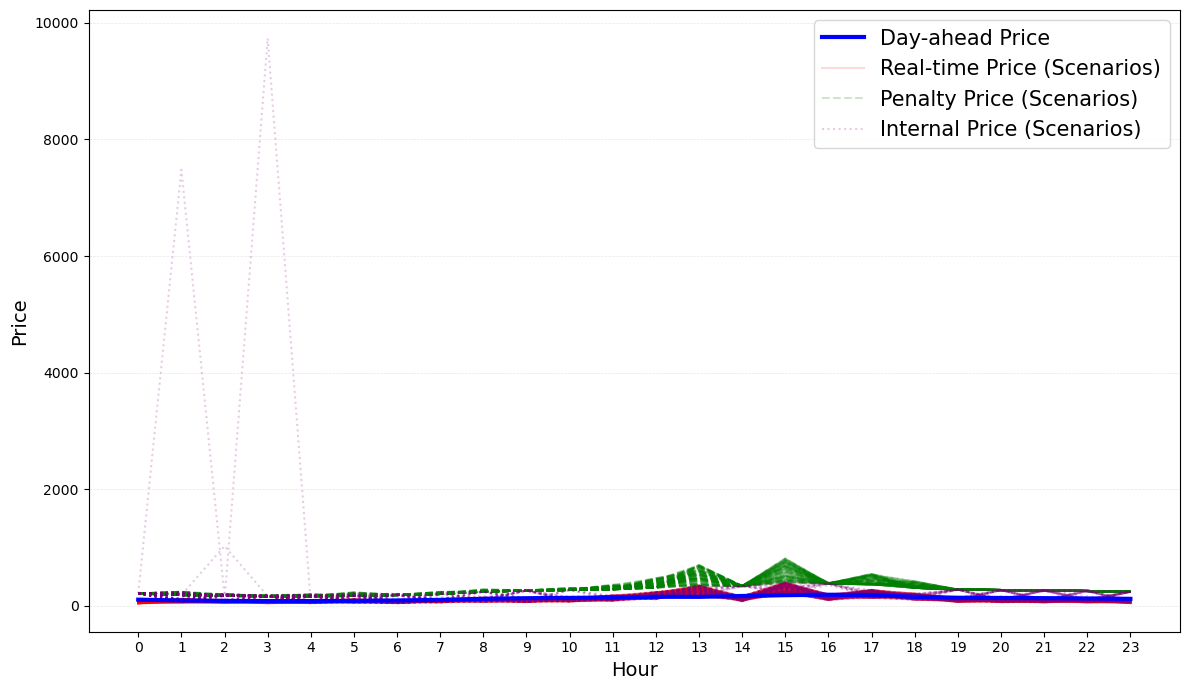

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# --- 1. CSV 파일 불러오기 ---
try:
    filename = f'./data/optimization_results_{SEED}.csv'
    df = pd.read_csv(filename)

    # --- 2. 데이터 추출 ---
    p_da_data = df[['t', 'P_DA']].drop_duplicates().sort_values('t')

    # --- 3. 그래프 그리기 ---
    plt.figure(figsize=(12, 7))

    # P_DA (Day-ahead Price) 플롯
    plt.plot(p_da_data['t'], p_da_data['P_DA'], linestyle='-', color='blue', label='Day-ahead Price', linewidth=3, zorder=10)

    # P_RT (Real-time Price) 시나리오 플롯
    scenarios = df['s'].unique()
    for i, s in enumerate(scenarios):
        scenario_data = df[df['s'] == s]
        if i == 0:
            plt.plot(scenario_data['t'], scenario_data['P_RT'], linestyle='-', color='red', alpha=0.15, label='Real-time Price (Scenarios)')
        else:
            plt.plot(scenario_data['t'], scenario_data['P_RT'], linestyle='-', color='red', alpha=0.15)

    # P_PN (Penalty Price) 시나리오 플롯
    for i, s in enumerate(scenarios):
        scenario_data = df[df['s'] == s]
        if i == 0:
            plt.plot(scenario_data['t'], scenario_data['P_PN'], linestyle='--', color='green', alpha=0.2, label='Penalty Price (Scenarios)')
        else:
            plt.plot(scenario_data['t'], scenario_data['P_PN'], linestyle='--', color='green', alpha=0.2)

    # --- 💡 P_IN (Internal Price) 시나리오 플롯 추가 ---
    for i, s in enumerate(scenarios):
        scenario_data = df[df['s'] == s]
        if i == 0:
            plt.plot(scenario_data['t'], scenario_data['P_IN'], linestyle=':', color='purple', alpha=0.2, label='Internal Price (Scenarios)')
        else:
            plt.plot(scenario_data['t'], scenario_data['P_IN'], linestyle=':', color='purple', alpha=0.2)
    # --- P_IN 플롯 추가 끝 ---

    # --- 4. 그래프 꾸미기 ---
    plt.xlabel('Hour', fontsize=14)
    plt.ylabel('Price', fontsize=14)
    plt.grid(True, which='both', linestyle='--', linewidth=0.5, axis='y', alpha=0.3)
    plt.xticks(ticks=range(0, 24))
    plt.legend(fontsize=15)
    plt.tight_layout()

    # --- 5. 그래프 보여주기 ---
    plt.show()

except FileNotFoundError:
    print(f"오류: '{filename}' 파일을 찾을 수 없습니다.")
    print("스크립트와 같은 폴더에 CSV 파일이 있는지 확인해주세요.")
except Exception as e:
    print(f"오류가 발생했습니다: {e}")

✅ Figure successfully saved to:
C:\Users\jangseohyun\SynologyDrive\workspace\opt-pricing\fig_price.pdf


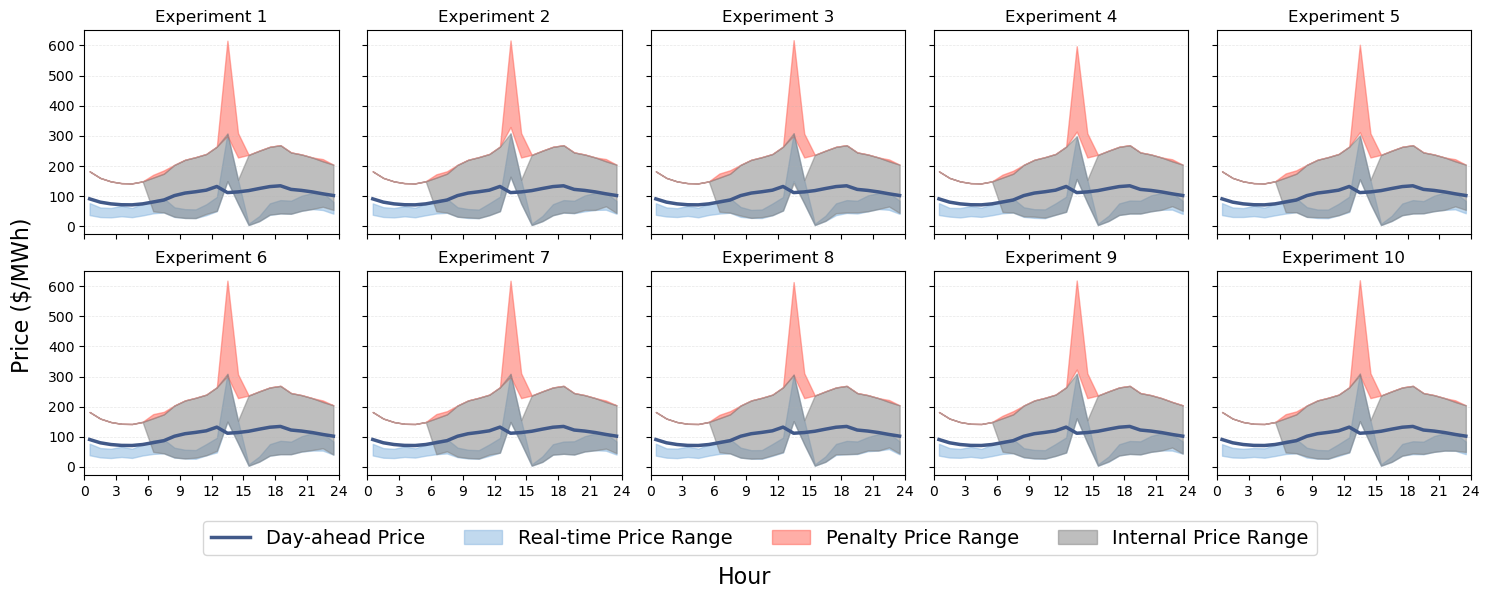

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- 1. 그래프 그리기 준비 ---
fig, axes = plt.subplots(2, 5, figsize=(15, 6), sharex=True, sharey=True)

# --- 2. 10개 파일에 대해 반복하여 플롯 그리기 ---
for i in range(1, 11):
    row = (i - 1) // 5
    col = (i - 1) % 5
    ax = axes[row, col]

    try:
        filename = f'./solution/optimization_results_{i}.csv'
        df = pd.read_csv(filename)

        # --- 데이터 필터링 ---
        if 'P_IN' not in df.columns and 'Internal_Price' in df.columns:
            df.rename(columns={'Internal_Price': 'P_IN'}, inplace=True)
        df['min_bound'] = df[['P_DA', 'P_RT', 'P_PN']].min(axis=1)
        df['max_bound'] = df[['P_DA', 'P_RT', 'P_PN']].max(axis=1)
        out_of_bounds_rows = df[(df['P_IN'] < df['min_bound'] - 1) | (df['P_IN'] > df['max_bound'] + 1)]
        scenarios_to_remove = out_of_bounds_rows['s'].unique()
        filtered_df = df[~df['s'].isin(scenarios_to_remove)]

        # --- 중점 시간 벡터 계산 (0.5, 1.5, ..., 23.5) ---
        # 중복 없이 정렬된 시각 리스트
        t_unique = np.sort(filtered_df['t'].unique())
        t_mid = t_unique + 0.5  # 각 구간의 중점

        # --- 각 서브플롯에 그래프 그리기 ---
        p_da_data = filtered_df[['t', 'P_DA']].drop_duplicates().sort_values('t')
        ax.plot(t_mid, p_da_data['P_DA'], linestyle='-', color='#415989',
                label='Day-ahead Price', linewidth=2.5, zorder=10)

        prt_range = filtered_df.groupby('t')['P_RT'].agg(['min', 'max'])
        ax.fill_between(t_mid, prt_range['min'], prt_range['max'],
                        color='#85B4DF', alpha=0.5, label='Real-time Price Range')

        ppn_range = filtered_df.groupby('t')['P_PN'].agg(['min', 'max'])
        ax.fill_between(t_mid, ppn_range['min'], ppn_range['max'],
                        color='#FF5E51', alpha=0.5, label='Penalty Price Range')

        pin_range = filtered_df.groupby('t')['P_IN'].agg(['min', 'max'])
        ax.fill_between(t_mid, pin_range['min'], pin_range['max'],
                        color='#7F7F7F', alpha=0.5, label='Internal Price Range')

        ax.set_title(f'Experiment {i}', fontsize=12)
        ax.grid(True, which='both', linestyle='--', linewidth=0.5, axis='y', alpha=0.3)
        ax.set_xlim(0, 24)  # 전체 시간 구간
        ax.set_xticks(np.arange(0, 25, 3))  # 0~24 눈금

    except FileNotFoundError:
        ax.text(0.5, 0.5, f'File {i} not found', ha='center', va='center')
        ax.set_title(f'Experiment {i}', fontsize=12, color='red')
    except Exception as e:
        ax.text(0.5, 0.5, f'Error plotting file {i}', ha='center', va='center')

# --- 3. 공통 레이블 및 범례 설정 ---
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=4,
           bbox_to_anchor=(0.51, 0.05), fontsize=14)

fig.supxlabel('Hour', fontsize=16)
fig.supylabel('Price ($/MWh)', fontsize=16, x=0.01)

# --- 4. 레이아웃 조정 및 그래프 보여주기 ---
plt.tight_layout()
plt.subplots_adjust(bottom=0.2)
save_dir = r"C:\Users\jangseohyun\SynologyDrive\workspace\opt-pricing"
os.makedirs(save_dir, exist_ok=True)  # 폴더 없으면 생성
save_path = os.path.join(save_dir, "fig_price.pdf")

# --- 저장 및 표시 ---
plt.savefig(save_path, format='pdf', bbox_inches='tight')
print(f"✅ Figure successfully saved to:\n{save_path}")


✅ Figure successfully saved to:
C:\Users\jangseohyun\SynologyDrive\workspace\opt-pricing\fig_marketcomp.pdf


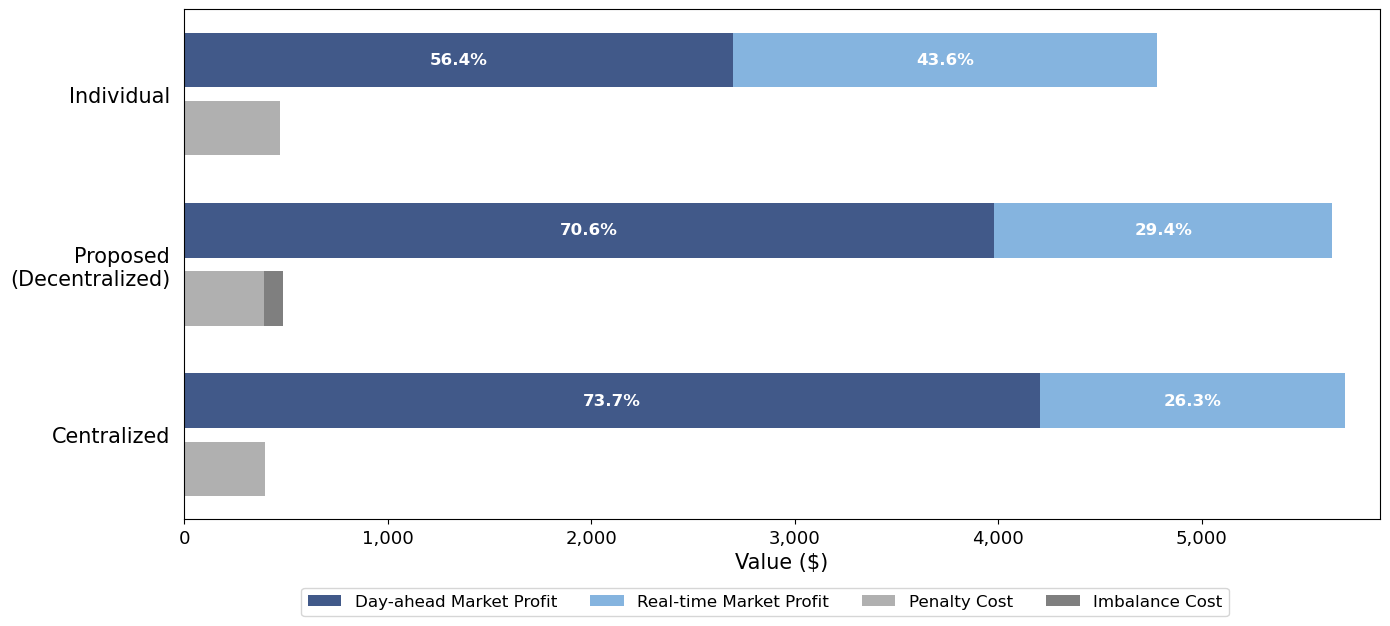

In [55]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Patch

# 1. Define Data
# --- 데이터 구조 정의 ---
# 6개의 막대에 대한 데이터 (순서가 중요합니다)
# 순서: 1.Indiv(Profit), 2.Indiv(Penalty), 3.Prop(Profit), 4.Prop(Penalty), 5.Cent(Profit), 6.Cent(Penalty)
data = {
    'Day-ahead Market': [
        2695.47468,  # 1. Indiv. Profit
        471.062,       # 2. Indiv. Penalty
        3981.218,      # 3. Prop. Profit
        392.444,       # 4. Prop. Penalty
        4204.554,      # 5. Centralized Profit
        398.644        # 6. Centralized Penalty
    ],
    'Real-time Market': [
        2083.263,  # 1. Indiv. Profit
        0,            # 2. Indiv. Penalty
        1660.373,      # 3. Prop. Profit
        0,        # 4. Prop. Penalty
        1500,      # 5. Centralized Profit
        0             # 6. Centralized Penalty
    ],
    'Imbalance Cost': [
        0,            # 1. Indiv. Profit (Imbalance Cost 없음)
        0,       # 2. Indiv. Imbalance Cost (가정된 값)
        0,            # 3. Prop. Profit (Imbalance Cost 없음)
        92.443,        # 4. Prop. Imbalance Cost (가정된 값)
        0,            # 5. Centralized Profit (Imbalance Cost 없음)
        0         # 6. Centralized Imbalance Cost (가정된 값)
    ]
}
# DataFrame을 사용하여 총합(totals) 계산 (이제 3개 요소를 포함)
df_combined = pd.DataFrame(data)
totals = df_combined.sum(axis=1).values

# --- Y축 위치 및 라벨 설정 (핵심) ---
y_positions = [0, 1,  2.5, 3.5,  5.0, 6.0] 
bar_height = 0.8 

y_tick_labels = ['Individual', 'Proposed\n(Decentralized)', 'Centralized']
y_tick_positions = [
    (y_positions[0] + y_positions[1]) / 2, 
    (y_positions[2] + y_positions[3]) / 2, 
    (y_positions[4] + y_positions[5]) / 2  
]

# --- 색상 정의 ---
markets = ['Day-ahead Market', 'Real-time Market', 'Imbalance Cost']
profit_colors = ['#415989', '#85B4DF'] 
penalty_color = '#B0B0B0'
imbalance_color = '#7F7F7F' # [!! 신규 !!] 연한 회색

# 2. Create Plot
fig, ax = plt.subplots(figsize=(14, 7)) 

# 누적 막대 그래프 그리기
# 1. Day-ahead Market 그리기
da_values = df_combined['Day-ahead Market'].values
da_colors = [profit_colors[0], penalty_color, 
             profit_colors[0], penalty_color, 
             profit_colors[0], penalty_color]
bars_da = ax.barh(y_positions, da_values, height=bar_height, label='Day-ahead Market', color=da_colors)

# 2. Real-time Market 그리기 (DA Market 오른쪽에 누적)
rt_values = df_combined['Real-time Market'].values
rt_colors = [profit_colors[1], penalty_color, 
             profit_colors[1], penalty_color, 
             profit_colors[1], penalty_color]
bars_rt = ax.barh(y_positions, rt_values, left=da_values, height=bar_height, label='Real-time Market', color=rt_colors)

# 3. [!! 신규 !!] Imbalance Cost 그리기 (RT Market 오른쪽에 누적)
imbalance_values = df_combined['Imbalance Cost'].values
imbalance_colors = [imbalance_color] * 6 
bars_imbalance = ax.barh(y_positions, imbalance_values, left=da_values + rt_values, 
                         height=bar_height, label='Imbalance Cost', color=imbalance_colors)

# 4. 퍼센트 텍스트 추가 (DA와 RT의 Profit 바에만)
# Day-ahead Market 텍스트
for i, bar in enumerate(bars_da):
    width = bar.get_width()
    if width > 0 and totals[i] > 0:
        percentage = width / totals[i] * 100
        if percentage > 4 and i % 2 == 0: 
            ax.text(bar.get_x() + width / 2, bar.get_y() + bar.get_height() / 2,
                    f'{percentage:.1f}%', ha='center', va='center', color='white', fontweight='bold', fontsize=12)

# Real-time Market 텍스트
for i, bar in enumerate(bars_rt):
    width = bar.get_width()
    if width > 0 and totals[i] > 0:
        percentage = width / totals[i] * 100
        if percentage > 4 and i % 2 == 0:
            ax.text(bar.get_x() + width / 2, bar.get_y() + bar.get_height() / 2,
                    f'{percentage:.1f}%', ha='center', va='center', color='white', fontweight='bold', fontsize=12)

# 5. Style the plot
ax.set_xlabel('Value ($)', fontsize=15)
ax.tick_params(axis='x', labelsize=13)

# --- [!! 수정 !!] X축 오른쪽에 여백 추가 ---
# 가장 긴 막대를 기준으로 15%의 오른쪽 여백을 줍니다.
ax.set_xlim(right=max(totals) * 1.03) 
# ----------------------------------------

# --- Y축 스타일링 ---
ax.set_yticks(y_tick_positions)      
ax.set_yticklabels(y_tick_labels)    
ax.tick_params(axis='y', labelsize=15, length=0, pad=10) 
ax.invert_yaxis() 

# X축 포맷터
ax.get_xaxis().set_major_formatter(
    plt.FuncFormatter(lambda x, p: format(int(x), ','))
)

# --- 범례 수정 ---
legend_elements = [
    Patch(facecolor=profit_colors[0], label='Day-ahead Market Profit'),
    Patch(facecolor=profit_colors[1], label='Real-time Market Profit'),
    Patch(facecolor=penalty_color, label='Penalty Cost'), # 라벨 수정
    Patch(facecolor=imbalance_color, label='Imbalance Cost') # [!! 신규 !!]
]
fig.legend(handles=legend_elements, loc='lower center', ncol=4, # ncol=4로 변경
           bbox_to_anchor=(0.55, 0.1), fontsize=12, title_fontsize=14)

# 레이아웃 조절
plt.tight_layout()
plt.subplots_adjust(bottom=0.25)
save_dir = r"C:\Users\jangseohyun\SynologyDrive\workspace\opt-pricing"
os.makedirs(save_dir, exist_ok=True)  # 폴더 없으면 생성
save_path = os.path.join(save_dir, "fig_marketcomp.pdf")

# --- 저장 및 표시 ---
plt.savefig(save_path, format='pdf', bbox_inches='tight')
print(f"✅ Figure successfully saved to:\n{save_path}")

In [70]:
import os; import pandas as pd
pd.options.display.float_format = '{:.3f}'.format
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
import numpy as np; import matplotlib.pyplot as plt
import gurobipy as gp; from gurobipy import GRB
from itertools import product; from tqdm import tqdm
import importlib
import functions_utils; import functions_data
import functions_optimize; import functions_eval
importlib.reload(functions_data); importlib.reload(functions_optimize)
importlib.reload(functions_eval); importlib.reload(functions_utils)
from functions_utils import *; from functions_data import *
from functions_optimize import *; from functions_eval import *
import time

S = 50
LEVEL = "high"
SEED = 1

generation_data, I, T = load_generation_data(date_filter="2022-07-18")
R, P_RT, K, K0, _, _, CRATE, DRATE = load_parameters(I, T, generation_data, S, LEVEL, SEED)
P_DA, P_PN = load_price_data(P_RT)
INEFF = 0.9

def plot_rt_scenarios(P_RT):
    # # plot_scenarios_for_generator(R,1)
    T, S = P_RT.shape
    hours = np.arange(0.5, T + 0.5)  # 0.5~23.5

    plt.figure(figsize=(10,5))

    for s in range(S):
        plt.plot(hours, P_RT[:, s], linestyle='-', alpha=0.3)

    mean_curve = np.mean(P_RT, axis=1)
    plt.plot(hours, mean_curve, color='#4471C4', linewidth=3, label="Original Data")

    plt.xlabel("Hour", fontsize=18)
    plt.ylabel("Price ($/MWh)", fontsize=18)
    plt.xlim(0, 24)
    plt.xticks(range(0, 25), fontsize=12)
    plt.legend(loc="upper left", fontsize=18)
    plt.tight_layout()

    save_dir = r"C:\Users\jangseohyun\SynologyDrive\workspace\opt-pricing"
    os.makedirs(save_dir, exist_ok=True)
    save_path = os.path.join(save_dir, "fig_pricenoise.pdf")

    plt.savefig(save_path, format='pdf', bbox_inches='tight')
    print(f"✅ Figure successfully saved to:\n{save_path}")


def plot_scenarios_for_generator(R, i):
    T = R.shape[1]
    S = R.shape[2]
    hours = np.arange(0.5, T + 0.5)  # 0.5~23.5

    plt.figure(figsize=(10,5))

    for s in range(S):
        plt.plot(hours, R[i, :, s]*1000, linestyle='-', alpha=0.3)
    mean_curve = np.mean(R[i, :, :]*1000, axis=1)
    plt.plot(hours, mean_curve, color='#4471C4', linewidth=3, label="Original Data")

    plt.xlabel("Hour", fontsize=18)
    plt.ylabel("Electricity Generated (kW)", fontsize=18)
    plt.xlim(0, 24)
    plt.xticks(range(0, 25), fontsize=12)
    plt.legend(loc="upper left", fontsize=18)
    plt.tight_layout()

    save_dir = r"C:\Users\jangseohyun\SynologyDrive\workspace\opt-pricing"
    os.makedirs(save_dir, exist_ok=True)  # 폴더 없으면 생성
    save_path = os.path.join(save_dir, "fig_generationnoise.pdf")

    # --- 저장 및 표시 ---
    plt.savefig(save_path, format='pdf', bbox_inches='tight')
    print(f"✅ Figure successfully saved to:\n{save_path}")

✅ 총 10개 파일을 불러왔습니다: 1033.csv, 1818.csv, 2502.csv, 2503.csv, 2634.csv, 2698.csv, 2816.csv, 545.csv, 665.csv, 690.csv
📊 데이터 Shape: I=10, T=24, S=50
✅ 시뮬레이션 초기화 완료: S=50, Randomness='high', Random Seed=1, M1=600.00, M2=3100.00
   - 개별 K 값: [200. 200. 400. 600. 100. 600. 300. 200. 300. 200.]


✅ Figure successfully saved to:
C:\Users\jangseohyun\SynologyDrive\workspace\opt-pricing\fig_pricenoise.pdf


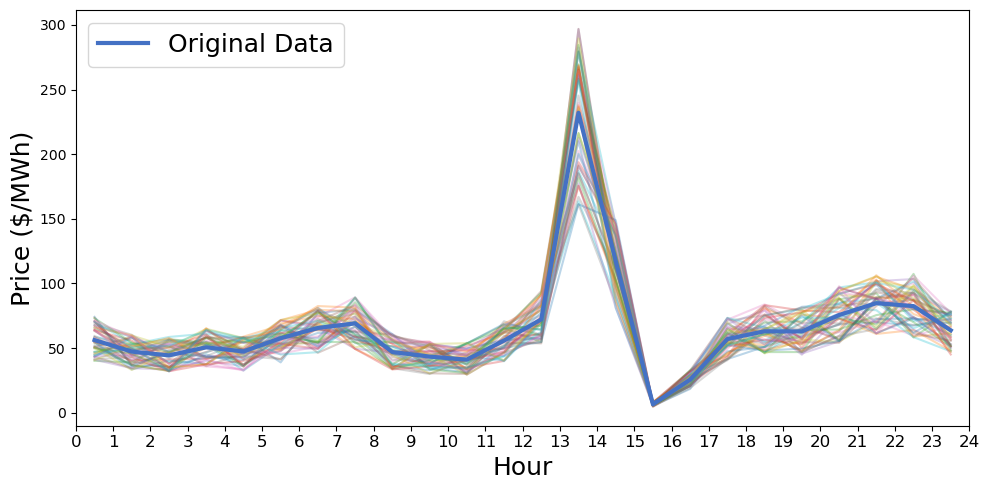

In [71]:
plot_rt_scenarios(P_RT)

✅ Figure successfully saved to:
C:\Users\jangseohyun\SynologyDrive\workspace\opt-pricing\fig_generationnoise.pdf


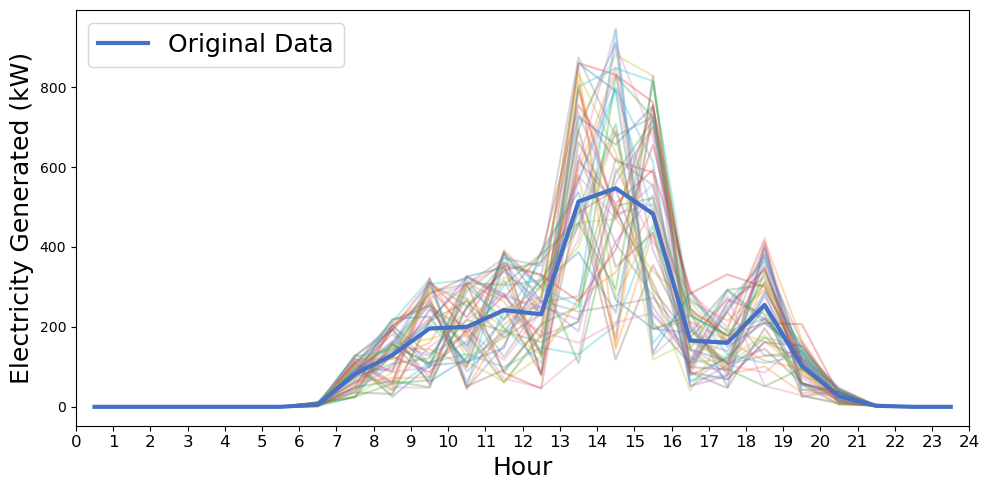

In [72]:
plot_scenarios_for_generator(R, 1)

In [ ]:
# ======================
# ⬇️ P_DA, P_RT 기반 통계 계산
# ======================

# DA: 단일 시나리오
havg = P_DA
hmin = P_DA
hmax = P_DA

# RT: 다중 시나리오 (axis=1 기준으로 통계)
savg = np.mean(P_RT, axis=1)
smin = np.min(P_RT, axis=1)
smax = np.max(P_RT, axis=1)

# 시간 벡터 (구간의 중점 기준)
hx = np.arange(0.5, len(P_DA) + 0.5)   # 0.5~23.5
sx = np.arange(0.5, len(P_RT) + 0.5)   # 0.5~23.5

# ======================
# ⬇️ Plot
# ======================
fig, (ax_avg, ax_rng) = plt.subplots(1, 2, figsize=(15, 3), sharey=True)

# 평균 비교
if 'USE_STEP_FOR_DA' in locals() and USE_STEP_FOR_DA:
    ax_avg.step(hx, havg, where='post', linewidth=1.5, label='DA Price Average', color='#415989')
else:
    ax_avg.plot(hx, havg, linewidth=1.5, label='DA Price Average', color='#415989')

ax_avg.plot(sx, savg, linewidth=1.2, linestyle='--', label='RT Price Average', color='#76A4CC')

ax_avg.set_xlabel('Hour', fontsize=13)
ax_avg.set_ylabel('Price ($/MWh)', fontsize=13)
ax_avg.grid(True, axis='y', alpha=0.2)
ax_avg.set_xlim(0, 24)                   # ⬅️ 0~24 범위
ax_avg.set_ylim(0, 250)
ax_avg.set_xticks(range(0, 25, 1))       # ⬅️ 0~24 눈금
ax_avg.legend(loc='upper left', fontsize=13)

# 범위 비교
ax_rng.fill_between(hx, hmin, hmax, alpha=0.5, label='DA Price Range', color='#5777BB')
ax_rng.fill_between(sx, smin, smax, alpha=0.3, label='RT Price Range', color='#85B4DF')
ax_rng.plot(sx, smin, linewidth=0.8, color='#5777BB', alpha=0.4)
ax_rng.plot(sx, smax, linewidth=0.8, color='#5777BB', alpha=0.4)

ax_rng.set_xlabel('Hour', fontsize=13)
ax_rng.grid(True, axis='y', alpha=0.2)
ax_rng.set_xlim(0, 24)
ax_rng.set_xticks(range(0, 25, 1))
ax_rng.legend(loc='upper left', fontsize=13)

plt.tight_layout()
plt.show()
